# Visualization of Test3 Venue Data

This notebook creates visualizations for:
1. **Line charts** showing temporal trends in stop proportions and unique device proportions by venue
2. **Heatmaps** showing the geographic distribution of unique devices by home geohash for each venue

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pygeohash as pgh
from matplotlib.patches import Rectangle
from matplotlib.colors import LinearSegmentedColormap, BoundaryNorm
import numpy as np
import geopandas as gpd
from shapely.geometry import box

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [21]:
# Load the stops data
stops_df = pd.read_csv('../../data/test3/test3_venues_stops.csv')

# Load the homes data
homes_df = pd.read_csv('../../data/test3/test3_venues_homes.csv')

# Load Toronto boundary data
toronto_gdf = gpd.read_file('../../data/geo/regions/GTA_CSD.gpkg')

# Convert year_month to datetime for better plotting
stops_df['date'] = pd.to_datetime(stops_df['year_month'], format='%Y%m')

print("Stops data shape:", stops_df.shape)
print("\nStops data sample:")
print(stops_df.head())

print("\n" + "="*50)
print("\nHomes data shape:", homes_df.shape)
print("\nHomes data sample:")
print(homes_df.head())

print("\n" + "="*50)
print("\nAll city names in GeoDataFrame:")
print(toronto_gdf['CSDNAME'].tolist())
print("\nLooking for Toronto:")
toronto_only = toronto_gdf[toronto_gdf['CSDNAME'] == 'Toronto']
print(f"Found {len(toronto_only)} row(s) for Toronto")
if len(toronto_only) > 0:
    print(toronto_only[['CSDNAME', 'CSDTYPE', 'LANDAREA']])

Stops data shape: (36, 7)

Stops data sample:
                   venue_name  year_month  stop_count  unique_devices  \
0              Lakeshore Arts      202501         102              57   
1  Museum of Contemporary Art      202501          68              61   
2   Toronto Reference Library      202501         763             642   
3              Lakeshore Arts      202502         131              67   
4  Museum of Contemporary Art      202502          66              56   

   stop_prop  unique_devices_prop       date  
0   0.000004             0.000013 2025-01-01  
1   0.000003             0.000013 2025-01-01  
2   0.000031             0.000142 2025-01-01  
3   0.000006             0.000015 2025-02-01  
4   0.000003             0.000013 2025-02-01  


Homes data shape: (1224, 3)

Homes data sample:
  home_geohash6                 venue_name  unique_device_count
0        dpz83w  Toronto Reference Library                  423
1        dpz2p5             Lakeshore Arts             

## Line Chart 1: Stop Proportion by Month

This chart shows the proportion of stops at each venue over time.

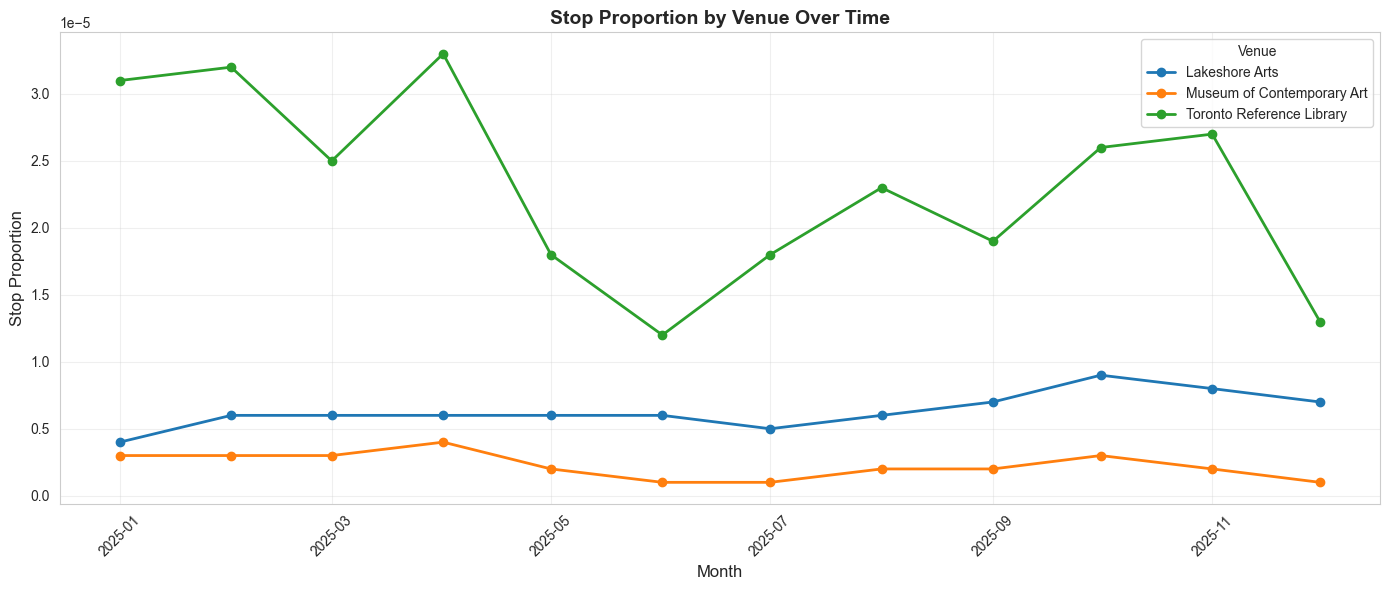

In [12]:
plt.figure(figsize=(14, 6))

# Plot each venue separately
for venue in stops_df['venue_name'].unique():
    venue_data = stops_df[stops_df['venue_name'] == venue]
    plt.plot(venue_data['date'], venue_data['stop_prop'], 
             marker='o', linewidth=2, label=venue)

plt.xlabel('Month', fontsize=12)
plt.ylabel('Stop Proportion', fontsize=12)
plt.title('Stop Proportion by Venue Over Time', fontsize=14, fontweight='bold')
plt.legend(title='Venue', fontsize=10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()

## Line Chart 2: Unique Devices Proportion by Month

This chart shows the proportion of unique devices visiting each venue over time.

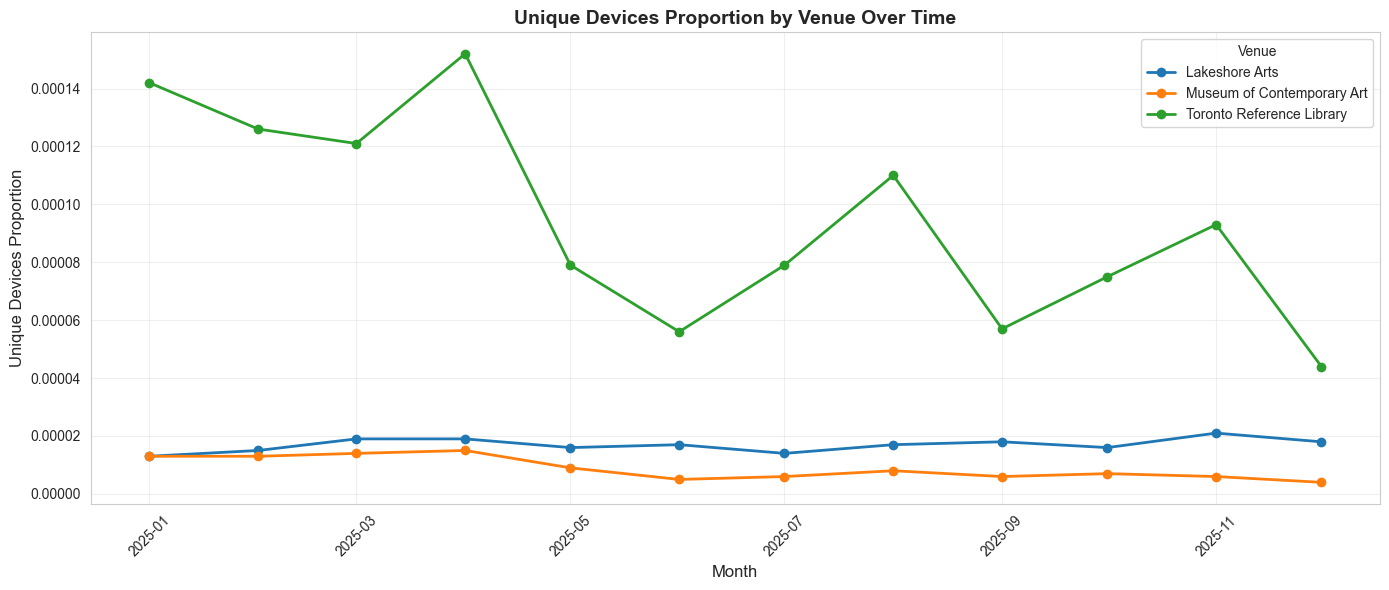

In [13]:
plt.figure(figsize=(14, 6))

# Plot each venue separately
for venue in stops_df['venue_name'].unique():
    venue_data = stops_df[stops_df['venue_name'] == venue]
    plt.plot(venue_data['date'], venue_data['unique_devices_prop'], 
             marker='o', linewidth=2, label=venue)

plt.xlabel('Month', fontsize=12)
plt.ylabel('Unique Devices Proportion', fontsize=12)
plt.title('Unique Devices Proportion by Venue Over Time', fontsize=14, fontweight='bold')
plt.legend(title='Venue', fontsize=10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()

## Heatmaps: Geographic Distribution by Home Geohash

For each venue, we'll create a heatmap showing where visitors' homes are located (based on geohash6).

In [27]:
def get_geohash_bounds(geohash):
    """Get the bounding box coordinates for a geohash."""
    lat, lon, lat_err, lon_err = pgh.decode_exactly(geohash)
    return {
        'min_lat': lat - lat_err,
        'max_lat': lat + lat_err,
        'min_lon': lon - lon_err,
        'max_lon': lon + lon_err
    }

def plot_geohash_heatmap(homes_df, venue_name, toronto_gdf, cmap='YlOrRd', n_bins=8):
    """
    Create a static heatmap showing geohash rectangles colored by unique device count.
    
    Parameters:
    -----------
    homes_df : DataFrame
        The homes data with geohash and unique_device_count columns
    venue_name : str
        Name of the venue to filter and plot
    toronto_gdf : GeoDataFrame
        GeoDataFrame containing Toronto boundary
    cmap : str
        Matplotlib colormap name (default: 'YlOrRd')
    n_bins : int
        Number of discrete color bins (default: 8)
    """
    # Filter data for the specific venue
    venue_data = homes_df[homes_df['venue_name'] == venue_name].copy()
    
    # Get Toronto boundary
    toronto_boundary = toronto_gdf[toronto_gdf['CSDNAME'] == 'Toronto']
    if len(toronto_boundary) == 0:
        print("Warning: Toronto boundary not found!")
        return
    
    # Reproject to Web Mercator (EPSG:3857)
    if toronto_boundary.crs != 'EPSG:3857':
        toronto_boundary = toronto_boundary.to_crs('EPSG:3857')
    
    # Get geohash bounds for each row and filter by Toronto boundary
    bounds_list = []
    for _, row in venue_data.iterrows():
        bounds = get_geohash_bounds(row['home_geohash6'])
        # Create a box for the geohash in WGS84
        geohash_box = box(bounds['min_lon'], bounds['min_lat'], 
                          bounds['max_lon'], bounds['max_lat'])
        
        # Convert to GeoDataFrame and reproject to Web Mercator
        geohash_gdf = gpd.GeoDataFrame([{'geometry': geohash_box}], crs='EPSG:4326')
        geohash_gdf = geohash_gdf.to_crs('EPSG:3857')
        
        # Check if geohash intersects with Toronto boundary
        if toronto_boundary.geometry.intersects(geohash_gdf.geometry.iloc[0]).any():
            # Get bounds in Web Mercator projection
            geom_bounds = geohash_gdf.geometry.iloc[0].bounds  # (minx, miny, maxx, maxy)
            bounds_list.append({
                'geohash': row['home_geohash6'],
                'count': row['unique_device_count'],
                'min_x': geom_bounds[0],
                'min_y': geom_bounds[1],
                'max_x': geom_bounds[2],
                'max_y': geom_bounds[3]
            })
    
    if len(bounds_list) == 0:
        print("Warning: No geohashes found within Toronto boundary!")
        return
    
    bounds_df = pd.DataFrame(bounds_list)
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(14, 10))
    
    # Create discrete color bins
    vmin = bounds_df['count'].min()
    vmax = bounds_df['count'].max()
    bounds_bins = np.linspace(vmin, vmax, n_bins + 1)
    norm = BoundaryNorm(bounds_bins, ncolors=n_bins)
    cmap_obj = plt.colormaps.get_cmap(cmap).resampled(n_bins)
    
    # Plot Toronto boundary first (as background)
    toronto_boundary.boundary.plot(ax=ax, color='black', linewidth=2, alpha=0.8)
    
    # Plot each geohash rectangle
    for _, row in bounds_df.iterrows():
        color = cmap_obj(norm(row['count']))
        rect = Rectangle(
            (row['min_x'], row['min_y']),
            row['max_x'] - row['min_x'],
            row['max_y'] - row['min_y'],
            facecolor=color,
            edgecolor='gray',
            alpha=0.8,
            linewidth=0.3
        )
        ax.add_patch(rect)
    
    # Get Toronto bounds for axis limits
    toronto_bounds = toronto_boundary.total_bounds  # [minx, miny, maxx, maxy]
    padding_x = (toronto_bounds[2] - toronto_bounds[0]) * 0.01
    padding_y = (toronto_bounds[3] - toronto_bounds[1]) * 0.01
    ax.set_xlim(toronto_bounds[0] - padding_x, toronto_bounds[2] + padding_x)
    ax.set_ylim(toronto_bounds[1] - padding_y, toronto_bounds[3] + padding_y)
    
    # Remove all axes, labels, ticks - make it look like a real map
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    
    # Add title at the top
    ax.set_title(f'{venue_name} - Visitor Home Locations', 
                 fontsize=16, fontweight='bold', pad=20)
    
    # Create horizontal colorbar at the bottom right
    # Create a new axes for the colorbar
    cax = fig.add_axes([0.62, 0.06, 0.28, 0.02])  # [left, bottom, width, height]
    
    sm = plt.cm.ScalarMappable(cmap=cmap_obj, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, cax=cax, orientation='horizontal', 
                        boundaries=bounds_bins, ticks=bounds_bins[::max(1, n_bins//6)])
    cbar.set_label('Unique Device Count', fontsize=10)
    cbar.ax.tick_params(labelsize=8)
    
    ax.set_aspect('equal', adjustable='box')
    plt.subplots_adjust(bottom=0.12)  # Leave space at bottom for colorbar
    plt.show()
    
    return fig, ax

print("Helper function defined successfully!")

Helper function defined successfully!


### Heatmap 1: Toronto Reference Library

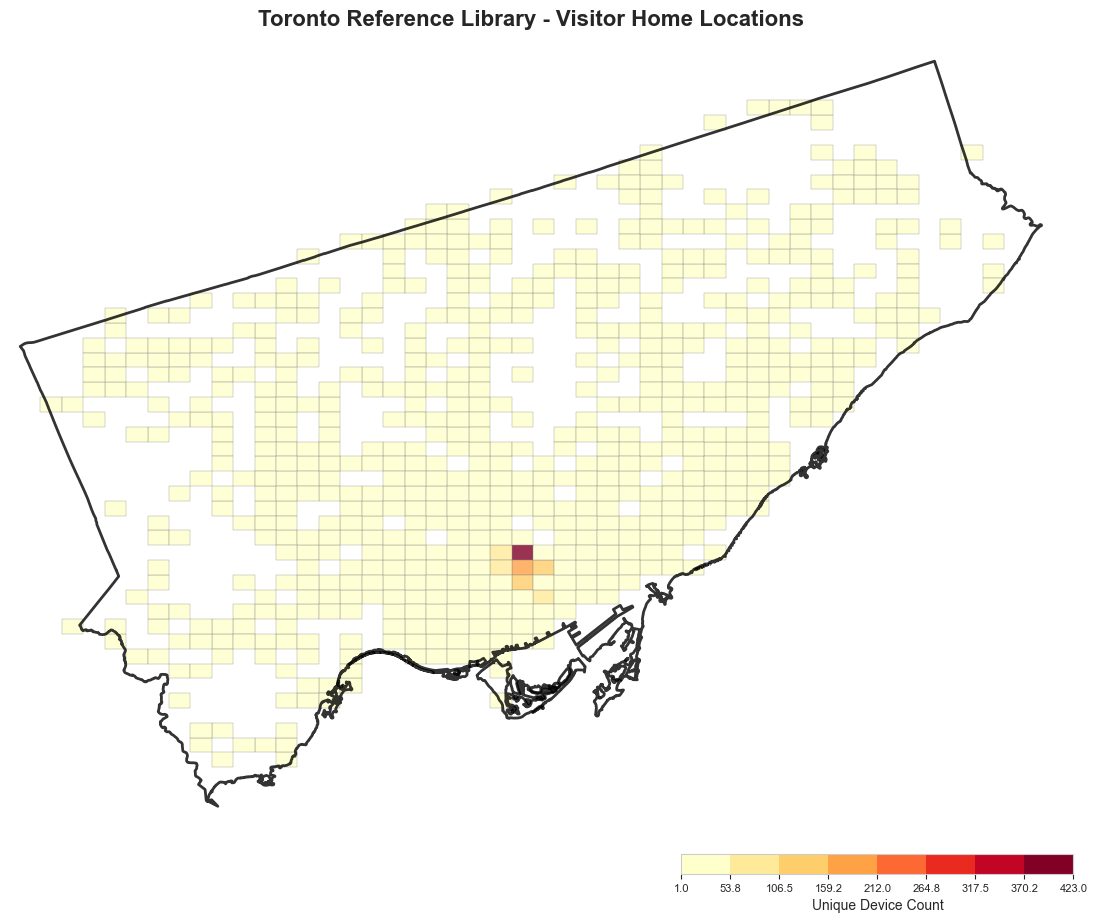

(<Figure size 1400x1000 with 2 Axes>,
 <Axes: title={'center': 'Toronto Reference Library - Visitor Home Locations'}>)

In [28]:
plot_geohash_heatmap(homes_df, 'Toronto Reference Library', toronto_gdf)

### Heatmap 2: Lakeshore Arts

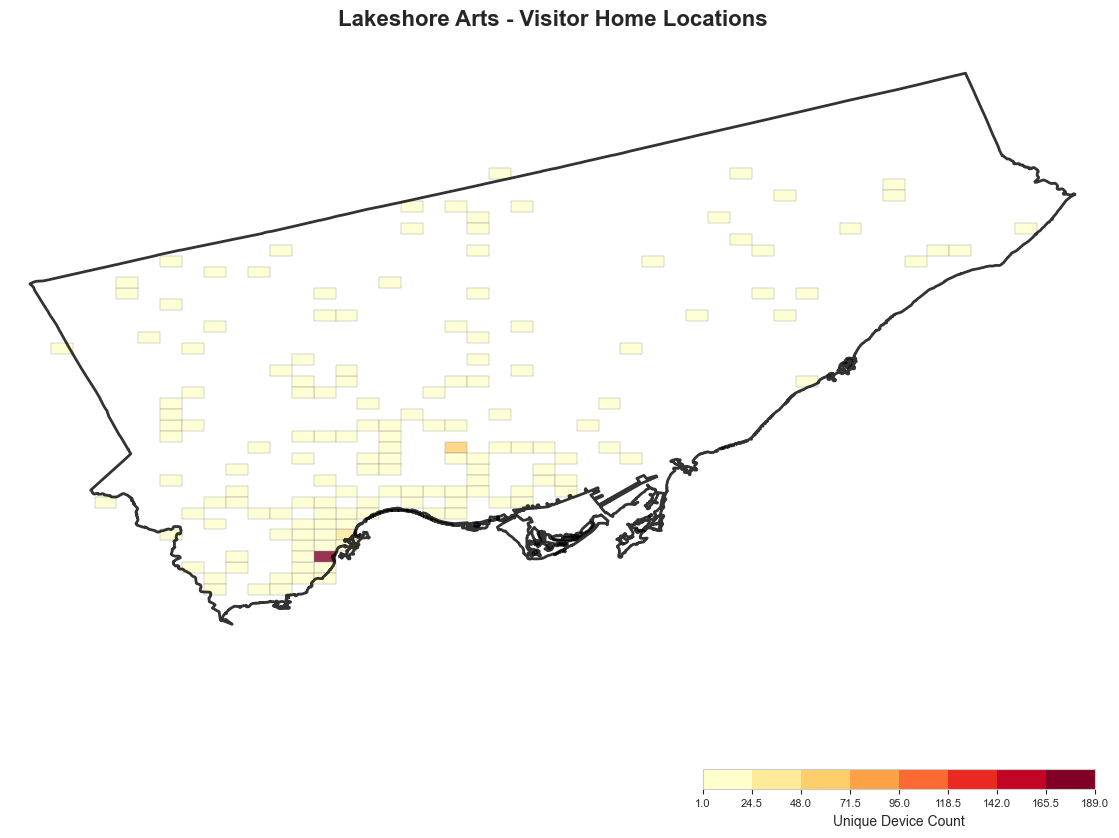

(<Figure size 1400x1000 with 2 Axes>,
 <Axes: title={'center': 'Lakeshore Arts - Visitor Home Locations'}>)

In [25]:
plot_geohash_heatmap(homes_df, 'Lakeshore Arts', toronto_gdf)

### Heatmap 3: Museum of Contemporary Art

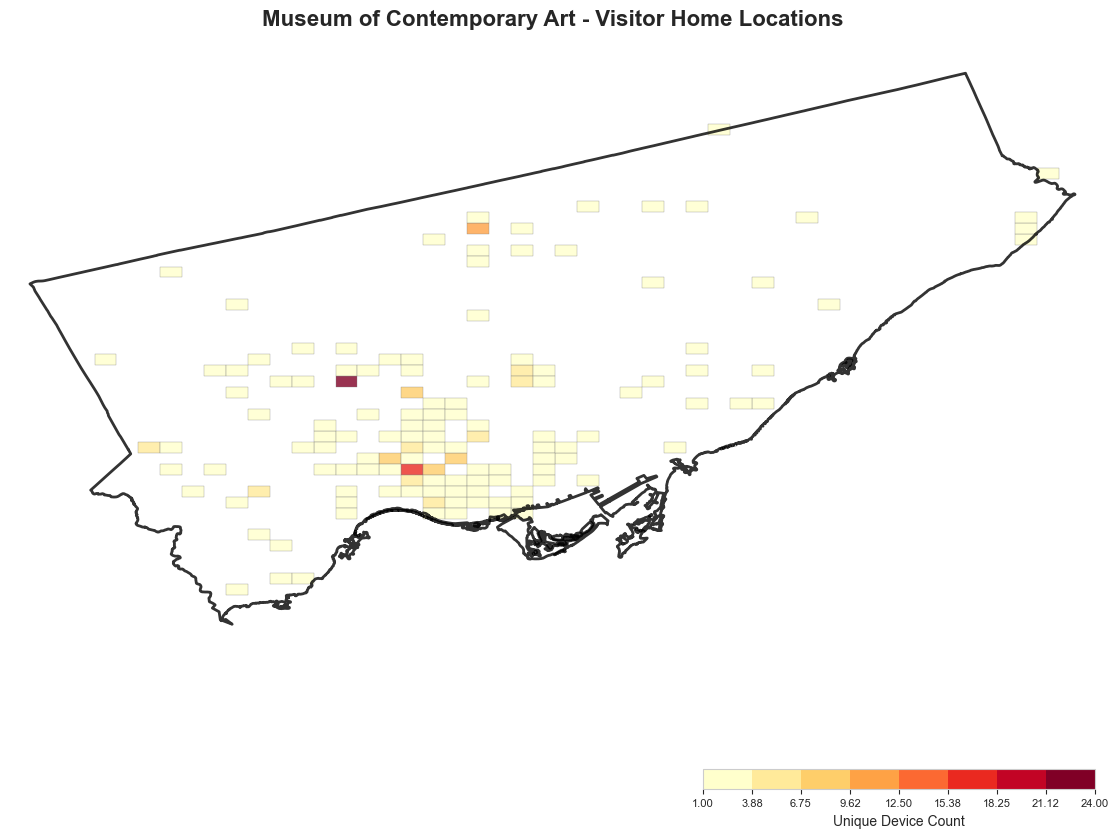

(<Figure size 1400x1000 with 2 Axes>,
 <Axes: title={'center': 'Museum of Contemporary Art - Visitor Home Locations'}>)

In [26]:
plot_geohash_heatmap(homes_df, 'Museum of Contemporary Art', toronto_gdf)

## Summary Statistics

In [18]:
# Summary statistics by venue
print("Total unique devices by venue (from homes data):")
print(homes_df.groupby('venue_name')['unique_device_count'].sum().sort_values(ascending=False))

print("\n" + "="*50)
print("\nAverage monthly stops by venue:")
print(stops_df.groupby('venue_name')['stop_count'].mean().sort_values(ascending=False))

print("\n" + "="*50)
print("\nAverage monthly unique devices by venue:")
print(stops_df.groupby('venue_name')['unique_devices'].mean().sort_values(ascending=False))

Total unique devices by venue (from homes data):
venue_name
Toronto Reference Library     3727
Lakeshore Arts                 654
Museum of Contemporary Art     327
Name: unique_device_count, dtype: int64


Average monthly stops by venue:
venue_name
Toronto Reference Library     562.000000
Lakeshore Arts                157.000000
Museum of Contemporary Art     54.666667
Name: stop_count, dtype: float64


Average monthly unique devices by venue:
venue_name
Toronto Reference Library     410.583333
Lakeshore Arts                 74.750000
Museum of Contemporary Art     38.166667
Name: unique_devices, dtype: float64
